# Graph Mining
## Lab 6: Spectral Embedding

In this lab, you will learn to embed the nodes of a graph in a vector space of low dimension. We consider the  embedding based on the top eigenvectors of the transition matrix $P=D^{-1}A$.

## Import

In [112]:
# !pip install scikit-network

In [113]:
from IPython.display import SVG

In [114]:
import numpy as np
from scipy import sparse
from matplotlib import pyplot as plt

In [115]:
from sknetwork.data import load_netset, karate_club
from sknetwork.embedding import Spectral
from sknetwork.ranking import PageRank
from sknetwork.visualization import visualize_graph

In [116]:
import pandas as pd

## Data

We will work on the following graphs (see the [NetSet](https://netset.telecom-paris.fr/) collection for details):
* Openflights (graph)
* WikiVitals (directed graph and bipartite graph)

In [117]:
openflights = load_netset('openflights')
wikivitals = load_netset('wikivitals')

Parsing files...
Done.
Parsing files...
Done.


## 1. Graphs

## Karate Club


We first consider the spectral embedding of the [karate club graph](https://en.wikipedia.org/wiki/Zachary%27s_karate_club).

In [118]:
dataset = karate_club(metadata=True)

In [119]:
adjacency = dataset.adjacency
position = dataset.position
labels_true = dataset.labels

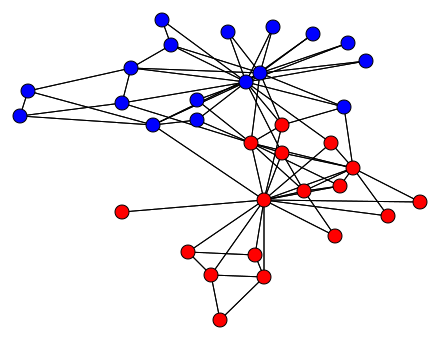

In [120]:
image = visualize_graph(adjacency, position, labels=labels_true)
SVG(image)

## To do

* Display the spectrum of the transition matrix (e.g., first 20 eigenvalues).
* What does the spectrum suggest?
* Display the graph with some eigenvectors.
* Display the embedding of the graph in dimension 2.
* Compare the clusters obtained with the sign of the first component of the embedding to the ground-truth clusters.

#### **Answers**

-  We observe that the existence of 4 nodes after the "big gap", suggesting the existence of 4 components or clusters. Also, the spectrum shows a single eigenvalue with value 1, proving that we have a single component.

- The 2 mistaken nodes in the clusters obtained with the sign of the first component are two ones really close to the cluster's boundary, which makes it more difficult for them to be correctly assigned.

In [128]:
spectral = Spectral(20, normalized=False)

In [122]:
import numpy as np

In [123]:
D = np.zeros(adjacency.shape)
degrees = adjacency.sum(axis=0)
print(degrees)


[[16  9 10  6  3  4  4  4  5  2  3  1  2  5  2  2  2  2  2  3  2  2  2  5
   3  3  2  4  3  4  4  6 12 17]]


In [124]:
degrees[0,1]

np.int64(9)

In [127]:
for i in range(adjacency.shape[0]):
    D[i,i] = degrees[0,i]

lapla = D - adjacency
print(lapla)
lapla = sparse.csr_matrix(lapla)


[[16. -1. -1. ... -1.  0.  0.]
 [-1.  9. -1. ...  0.  0.  0.]
 [-1. -1. 10. ...  0. -1.  0.]
 ...
 [-1.  0.  0. ...  6. -1. -1.]
 [ 0.  0. -1. ... -1. 12. -1.]
 [ 0.  0.  0. ... -1. -1. 17.]]


In [129]:
spectral.fit(adjacency) 

Spectral(n_components=20, decomposition='rw', regularization=-1, normalized=False)

In [130]:
# eigenvalues (adding the first)
eigenvalues = [1] + list(spectral.eigenvalues_)

In [131]:
# eigenvectors
eigenvectors = spectral.eigenvectors_

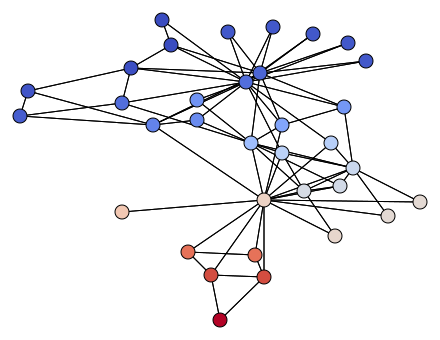

In [13]:
# display an eigenvector
image = visualize_graph(adjacency, position, scores=eigenvectors[:, 0])
SVG(image)

In [132]:
print(eigenvalues)

[1, np.float64(0.8677276707704834), np.float64(0.7129510146149647), np.float64(0.6126867673898699), np.float64(0.38776945979969224), np.float64(0.35100705333079973), np.float64(0.29279179750584783), np.float64(0.2600420106991579), np.float64(0.22908938314886906), np.float64(0.17705714766180958), np.float64(0.13516705541938023), np.float64(0.09318399841352476), np.float64(3.3306690738754696e-16), np.float64(2.220446049250313e-16), np.float64(1.1102230246251565e-16), np.float64(1.1102230246251565e-16), np.float64(1.1102230246251565e-16), np.float64(0.0), np.float64(0.0), np.float64(-2.220446049250313e-16), np.float64(-2.220446049250313e-16)]


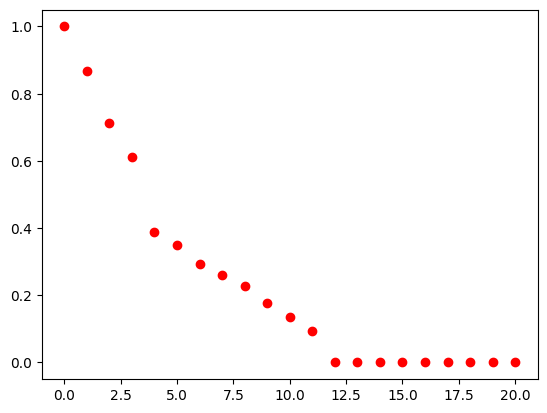

In [14]:
#### Display the spectrum of the transition matrix (e.g., first 20 eigenvalues).
x = [i for i in range(len(eigenvalues))]
plt.scatter(x, eigenvalues, c='r')

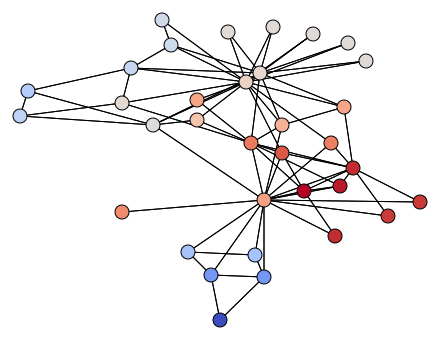

In [15]:
#### Display the graph with some eigenvectors
image = visualize_graph(adjacency, position, scores=eigenvectors[:, 1])
SVG(image)

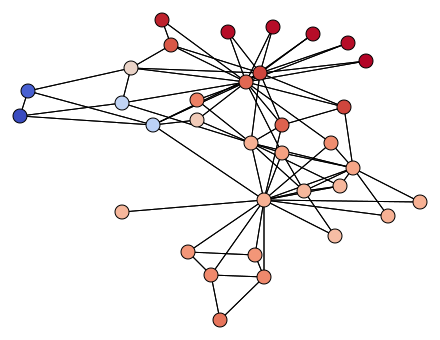

In [16]:
image = visualize_graph(adjacency, position, scores=eigenvectors[:, 2])
SVG(image)

In [17]:
#### Display the embedding of the graph in dimension 2
embedding = spectral.transform()
embedding.shape

(34, 20)

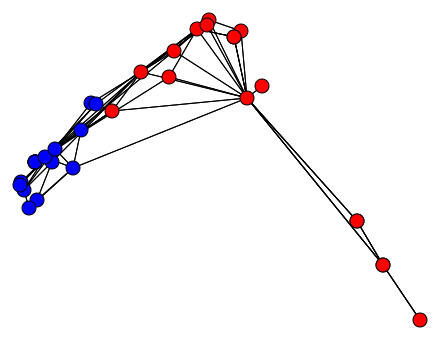

In [18]:
image = visualize_graph(adjacency, embedding, labels=labels_true)
SVG(image)

In [19]:
 #### Compare the clusters obtained with the sign of the first component of the embedding to the ground-truth clusters.
label_emb = embedding[:,0] > 0
label_emb = [1 if label==True else 0 for label in label_emb]

In [20]:
np.count_nonzero(label_emb==labels_true)

32

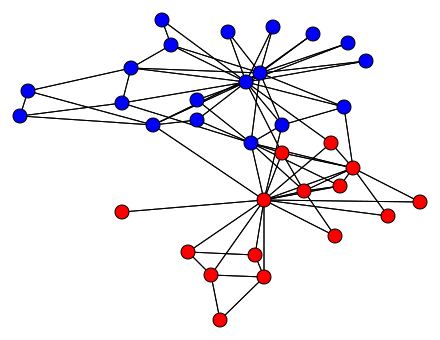

In [21]:
image = visualize_graph(adjacency, position, labels=label_emb)
SVG(image)

## Openflights


We now consider a larger graph. We use spectral embedding in dimension 20 to cluster the graph by k-means in the embedding space.

In [22]:
dataset = openflights

In [23]:
adjacency = dataset.adjacency
position = dataset.position
names = dataset.names

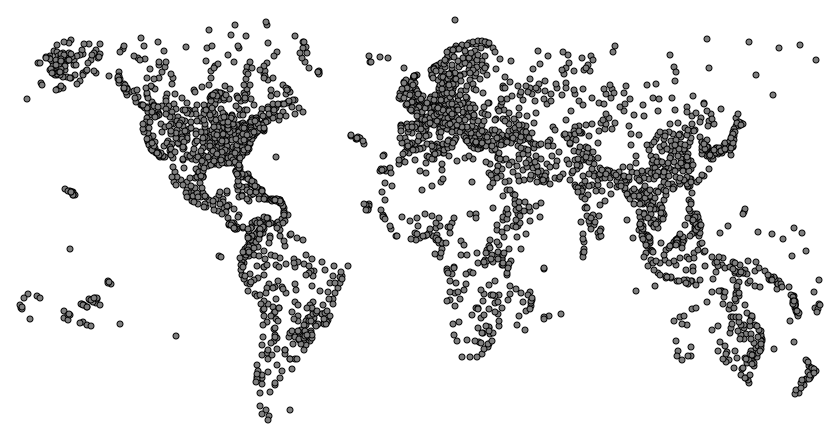

In [24]:
image = visualize_graph(adjacency, position, width=800, height=400, node_size=3, display_edges=False)
SVG(image)

## To do

* Display the same world map with 8 clusters found by k-means in the embedding space. You can use ``scikit-learn``for k-means.
* Do the same without normalization on the unit sphere (``normalized=False``).<br> Interpret the results. <br>**Hint:** Compute the Euclidean norm of the centroid of each cluster in the embedding space.

#### **Answers**

- We observe that the algorithm K-means faces difficulties when clustering the world map with normalized=False. That happens because there some high degree nodes realy concentrated, which leads them to have a higher impact in the unnormalized embeddings. Finally, these embeddings are all clustered together because they were all heavily influenciated by the high degree and concentrated nodes (we can see that the norm of one cluster is much bigger than the others). When we set normalize=True, the embeddings reflect better the graph structure, rather than only scaling up with the degree. That gives us a much more better clustering and much more equilibrated centroid norms, as we can see.

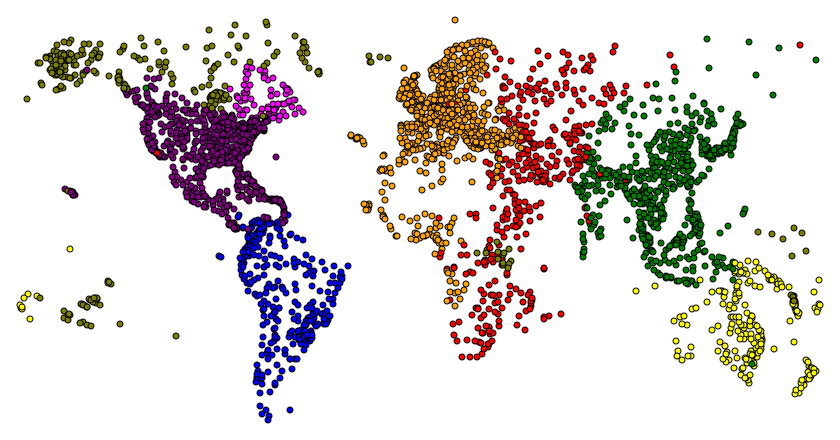

In [25]:
#### Display the same world map with 8 clusters found by k-means in the embedding space. You can use scikit-learnfor k-means.
spectral = Spectral(20, normalized=True)
embedding = spectral.fit_transform(adjacency)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(embedding)
pred_labels = kmeans.labels_
image = visualize_graph(adjacency, position, width=800, height=400, node_size=3, display_edges=False, labels=pred_labels)
SVG(image)

In [26]:
#### Compute the euclidian norm of the centroid of each cluster in the embedding space
cluster_centers = kmeans.cluster_centers_
for centroid in cluster_centers:
  euc_norm = np.linalg.norm(centroid)
  print(f"Euclidian  norm {euc_norm}")

Euclidian  norm 0.9912511350070456
Euclidian  norm 0.9155014749517224
Euclidian  norm 0.9668267936434133
Euclidian  norm 0.9799838216949429
Euclidian  norm 0.9754166927817279
Euclidian  norm 0.8561631172710339
Euclidian  norm 0.737254722028699
Euclidian  norm 0.30686439003563987


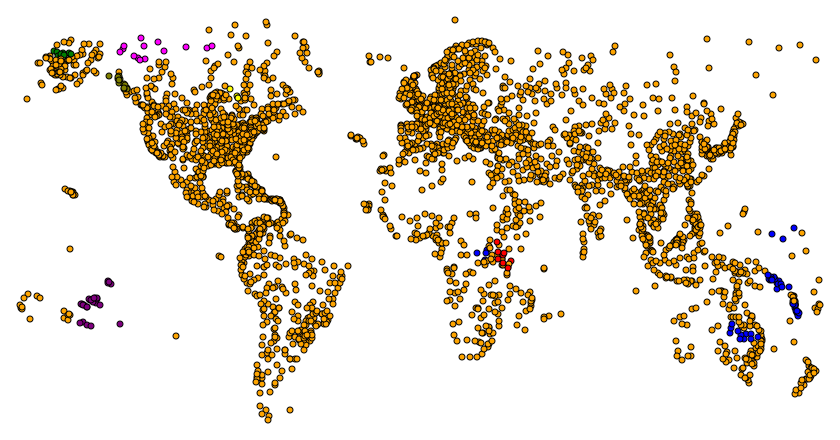

In [27]:
#### Do the same without normalization on the unit sphere (normalized=False)
spectral = Spectral(20, normalized=False)
embedding = spectral.fit_transform(adjacency)

kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(embedding)
pred_labels = kmeans.labels_
image = visualize_graph(adjacency, position, width=800, height=400, node_size=3, display_edges=False, labels=pred_labels)
SVG(image)

In [28]:
#### Compute the euclidian norm of the centroid of each cluster in the embedding space
cluster_centers = kmeans.cluster_centers_
for centroid in cluster_centers:
  euc_norm = np.linalg.norm(centroid)
  print(f"Euclidian norm {euc_norm}")

Euclidian norm 0.050266729030363444
Euclidian norm 0.17142900601637515
Euclidian norm 0.1545425818883749
Euclidian norm 0.0017416187447701398
Euclidian norm 0.0829598054686942
Euclidian norm 0.3108099542658546
Euclidian norm 0.12142787072597025
Euclidian norm 0.11676989085195523


## 2. Directed graphs and bipartite graphs

We now work on directed graph and bipartite graphs. We measure proximity between nodes in the embedding space in terms of [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity). Equivalently, we project the vectors on the unit sphere.

In [29]:
spectral = Spectral(20, normalized=True)

## Wikipedia Vitals

In [30]:
dataset = wikivitals

In [31]:
adjacency = dataset.adjacency
biadjacency = dataset.biadjacency
names = dataset.names
words = dataset.names_col
labels = dataset.labels
names_labels = dataset.names_labels
labels_hierarchy = dataset.labels_hierarchy
names_labels_hierarchy = dataset.names_labels_hierarchy

## To do

We first consider the spectral embedding of the graph of links in dimension 20.

* List the 20 articles that are closest to **Vincent van Gogh** in terms of cosine similarity in the embedding space. Compare with the top articles obtained with Personalized PageRank.
* Display the 3D-plot of each of the 11 labels in the embedding space (top 3 dimensions). <br>You might represent each label by a point located at the centroid of the corresponding articles, with a size proportional to the number of articles. Use ``plotly`` for an interactive plot. Interpret the results.
* Display the dendrogram of the hierarchical clustering of the top-100 articles on **Arts** (in terms of Personalized PageRank). You might use the [Ward method](https://en.wikipedia.org/wiki/Ward%27s_method) in the embedding space. Comment the results.

## **Answers**

- The top20 from Cosine Similarity and Personalized PageRank differ in the elements retrieved.

- We observe that the closest the nodes are the closer should be their articles in the graph structure. "History" and "Society and Social Sciences",  for example, are to close node in the plot, which is perfectly reasonable.

- It is interesting to notice the dendogram clearly dividing the Music domain and other domains from "Art" topics. Even inside this last, we observe, for example, Cinema related topics being close to each other.

In [32]:
import plotly.express as px

In [33]:
from scipy.cluster.hierarchy import linkage

In [34]:
#### List the 20 articles that are closest to Vincent van gogh in terms of cosine similarity in the embedding space.

  # Compute embeddings
embeddings = spectral.fit_transform(adjacency)

  # Find Van Gogh's index
idx_vg = np.where(names == "Vincent van Gogh")[0][0]

  # Compute cosine similarity of Van Gogh's embedding to all others
emb_vg = embeddings[idx_vg]
denominator = (np.linalg.norm(emb_vg) * np.linalg.norm(embeddings, axis=1))
cosine_sims = np.dot(embeddings, emb_vg) / denominator

  # Find 20 closest
top20_cos = np.argsort(cosine_sims)[::-1][:21]

  # List them
for i,top in enumerate(top20_cos):
  print(f"Cosine: {i}. {names[top]}")

Cosine: 0. Vincent van Gogh
Cosine: 1. Georges Seurat
Cosine: 2. Paul Cézanne
Cosine: 3. Paul Gauguin
Cosine: 4. Henri de Toulouse-Lautrec
Cosine: 5. Franz Marc
Cosine: 6. Post-Impressionism
Cosine: 7. Edvard Munch
Cosine: 8. Henri Rousseau
Cosine: 9. Musée National d'Art Moderne
Cosine: 10. Performance art
Cosine: 11. Henri Matisse
Cosine: 12. Marcel Duchamp
Cosine: 13. Abstract art
Cosine: 14. Modern art
Cosine: 15. Impressionism
Cosine: 16. Antonin Artaud
Cosine: 17. Constantin Brâncuși
Cosine: 18. National Gallery of Art
Cosine: 19. Outsider art
Cosine: 20. Max Ernst


In [35]:
#### Compare with the top articles obtained with Personalized PageRank.
pagerank = PageRank()

weights = np.zeros(adjacency.shape[0])

weights[idx_vg] = 1

scores = pagerank.fit_predict(adjacency, weights=weights)

top20_pg = np.argsort(scores)[::-1][:21]

for i,top in enumerate(top20_pg):
  print(f"Pagerank: {i}. {names[top]}")


Pagerank: 0. Vincent van Gogh
Pagerank: 1. World War I
Pagerank: 2. Metropolitan Museum of Art
Pagerank: 3. Impressionism
Pagerank: 4. Pablo Picasso
Pagerank: 5. Modernism
Pagerank: 6. Paul Cézanne
Pagerank: 7. Cubism
Pagerank: 8. National Gallery of Art
Pagerank: 9. Post-Impressionism
Pagerank: 10. Claude Monet
Pagerank: 11. Paul Gauguin
Pagerank: 12. Symbolism (arts)
Pagerank: 13. Modern art
Pagerank: 14. Museum of Modern Art
Pagerank: 15. Art Nouveau
Pagerank: 16. Expressionism
Pagerank: 17. BBC
Pagerank: 18. Wassily Kandinsky
Pagerank: 19. Henri Matisse
Pagerank: 20. Hermitage Museum


In [36]:
  # Compare cosine and pagerank
both = np.intersect1d(top20_cos, top20_pg)
only_cos = np.setdiff1d(top20_cos, top20_pg)
only_pg = np.setdiff1d(top20_pg, top20_cos)

print("Both: ")
for idx in both:
    print(names[idx])


print("\nOnly in cos: ")
for idx in only_cos:
    print(names[idx])

print("\nOnly in pg: ")
for idx in only_pg:
    print(names[idx])

Both: 
Henri Matisse
Impressionism
Modern art
National Gallery of Art
Paul Cézanne
Paul Gauguin
Post-Impressionism
Vincent van Gogh

Only in cos: 
Abstract art
Antonin Artaud
Constantin Brâncuși
Edvard Munch
Franz Marc
Georges Seurat
Henri Rousseau
Henri de Toulouse-Lautrec
Marcel Duchamp
Max Ernst
Musée National d'Art Moderne
Outsider art
Performance art

Only in pg: 
Art Nouveau
BBC
Claude Monet
Cubism
Expressionism
Hermitage Museum
Metropolitan Museum of Art
Modernism
Museum of Modern Art
Pablo Picasso
Symbolism (arts)
Wassily Kandinsky
World War I


In [37]:
# !pip install -U nbformat

In [38]:
#### Display the 3D-plot of each of the 11 labels in the embedding space (top 3 dimensions).

emb_3d = embeddings[:, :3]

rows = []

for label_id, label_name in enumerate(names_labels):
    idx = np.where(labels == label_id)[0]
    centroid = emb_3d[idx].mean(axis=0)

    rows.append({
        "label": label_name,
        "x": centroid[0],
        "y": centroid[1],
        "z": centroid[2],
        "size": len(idx)
    })

df = pd.DataFrame(rows)

fig = px.scatter_3d(
    df,
    x="x", y="y", z="z",
    color="label",
    size="size",
    hover_name="label",
    hover_data={"size": True},
    title="Wikipedia Vitals labels in 3d embedding space"
)

fig.update_traces(marker=dict(opacity=0.8))
fig.show()

In [39]:
print(names_labels)

['Arts' 'Biological and health sciences' 'Everyday life' 'Geography'
 'History' 'Mathematics' 'People' 'Philosophy and religion'
 'Physical sciences' 'Society and social sciences' 'Technology']


In [40]:
print(names)

['0' '1' '100 metres' ... 'Łódź' 'Śāriputra' '−1']


In [41]:
### Display the dendrogram of the hierarchical clustering of the top-100 articles on Arts (in terms of Personalized PageRank).
  # Apply pagerank on Arts
pagerank = PageRank()

weights = np.zeros(adjacency.shape[0])

label_arts = np.where(names_labels == "Arts")[0][0]
articles_arts = np.where(labels == label_arts)[0]

weights[articles_arts] = 1

scores = pagerank.fit_predict(adjacency, weights=weights)
arts_scores = scores[articles_arts]
top100_local = np.argsort(arts_scores)[::-1][:100]
top100_arts = articles_arts[top100_local]

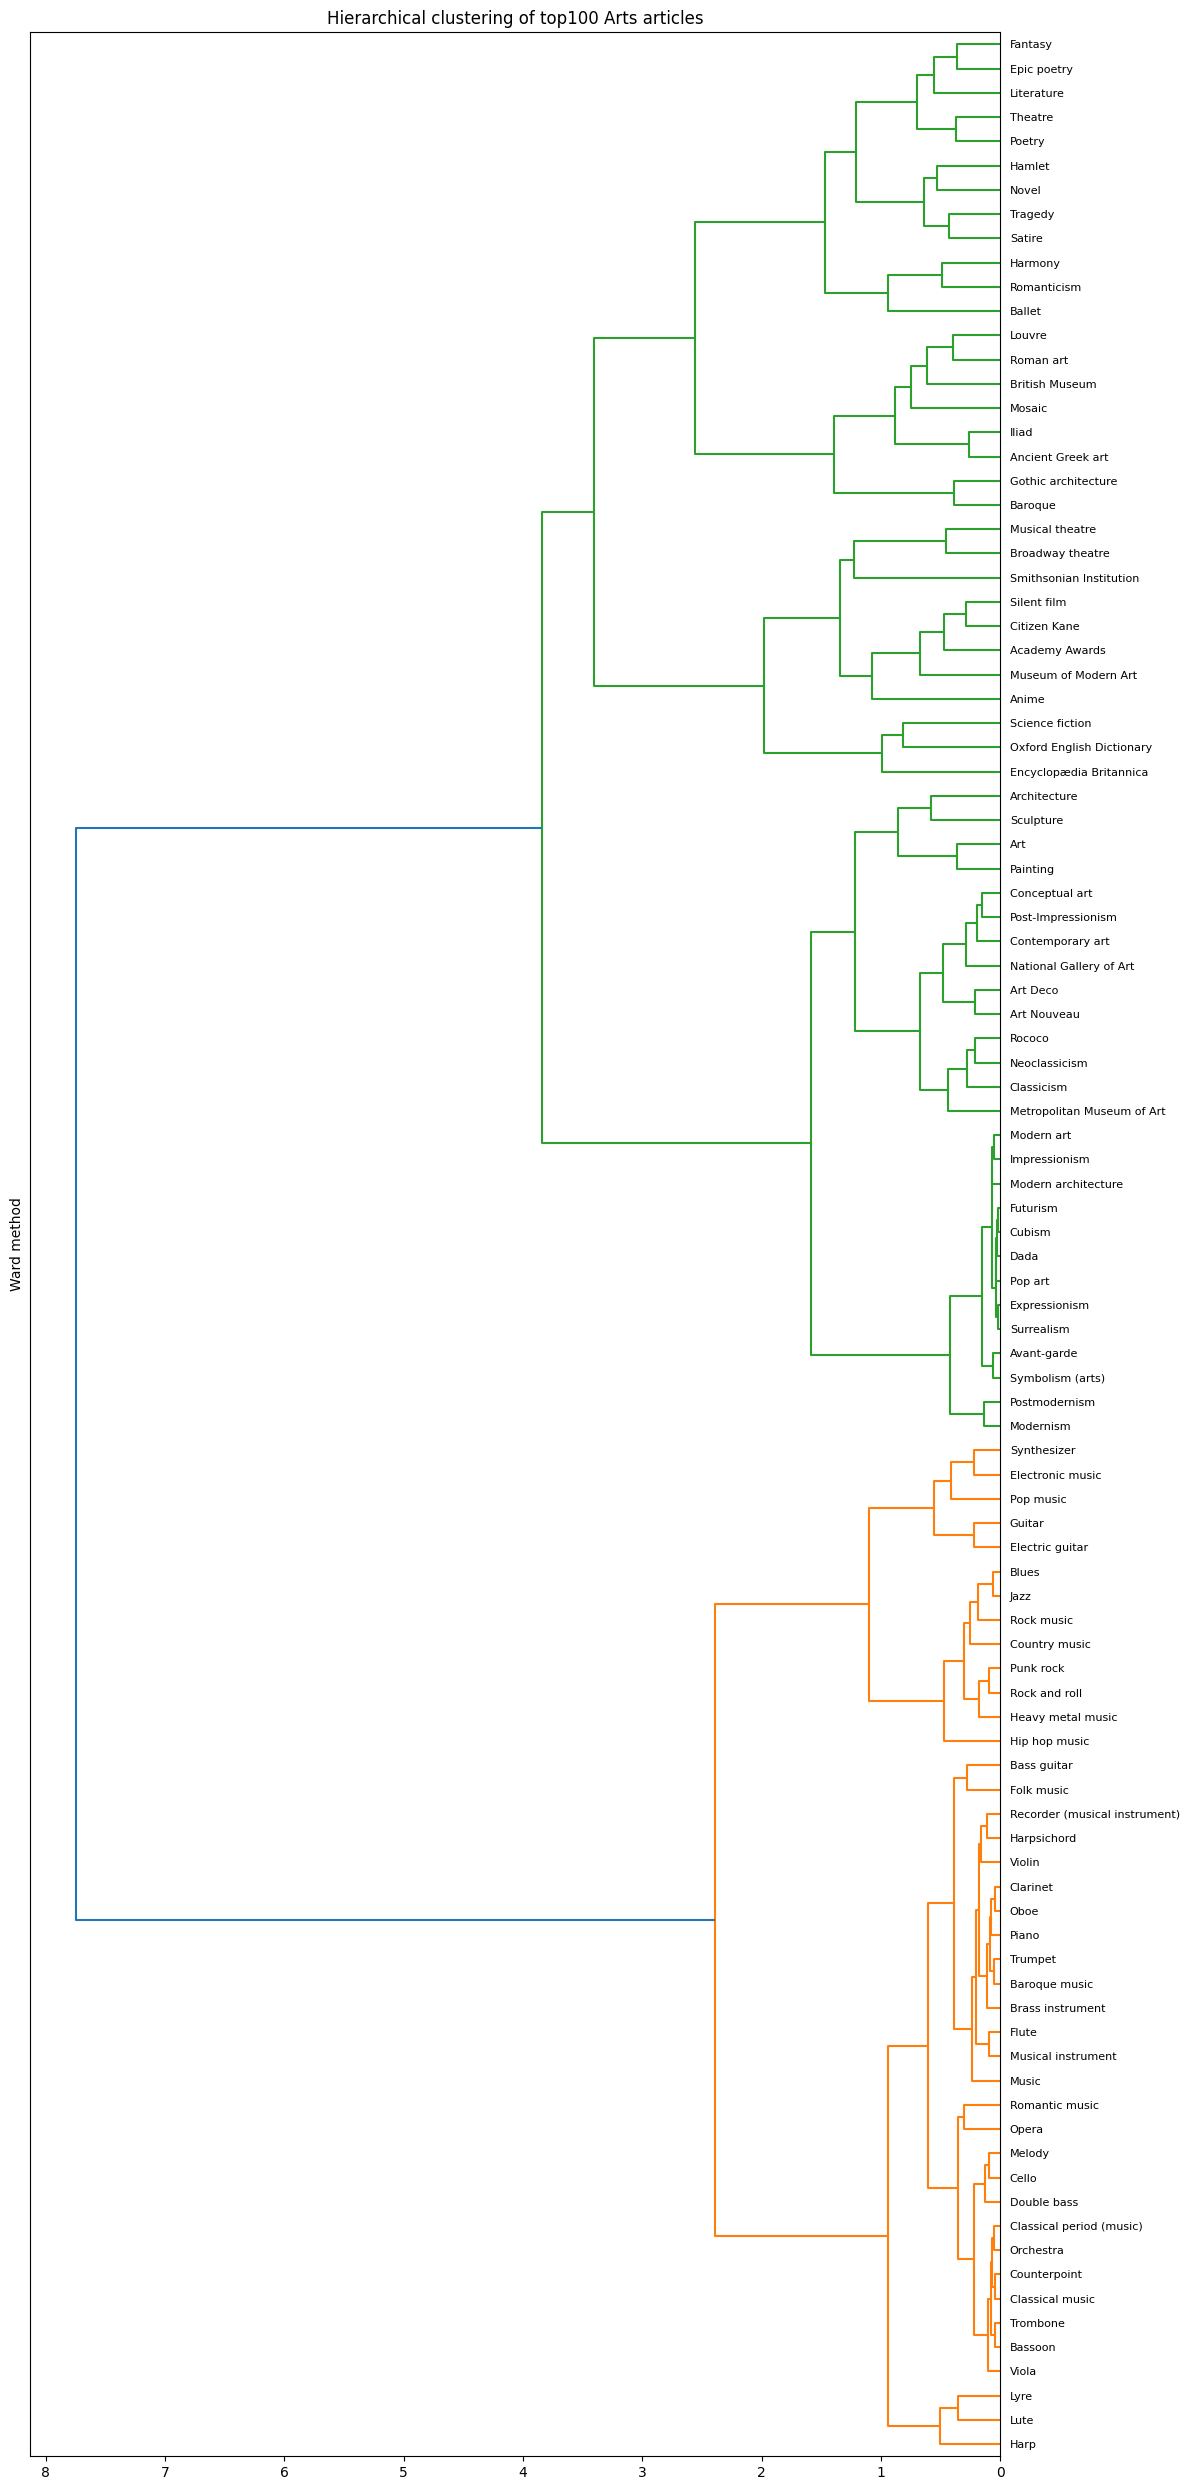

In [42]:
#### use the Ward method in the embedding space
from scipy.cluster.hierarchy import dendrogram
arts_emb = embeddings[top100_arts]

Z = linkage(arts_emb, method='ward')

plt.figure(figsize=(12, 25))

dendrogram(
    Z,
    labels=names[top100_arts],
    orientation="left",
    leaf_font_size=8
)

plt.title("Hierarchical clustering of top100 Arts articles")
plt.ylabel("Ward method")
plt.tight_layout()
plt.show()

## To do

* Repeat the same experiments on the bipartite graph between articles and words.
* List the 10 articles and the 10 words that are closest to the word **painting** in the embedding space.

In [43]:
#### List the 20 articles that are closest to **Vincent van Gogh** in terms of cosine similarity in the embedding space.
from scipy.sparse import bmat
import numpy as np

B = biadjacency
A_bip = bmat([
    [None, B],
    [B.T, None]
], format="csr")

embeddings = spectral.fit_transform(A_bip)

n_articles = len(names)
article_emb = embeddings[:n_articles]

# Find Van Gogh's index
idx_vg = np.where(names == "Vincent van Gogh")[0][0]

# Cosine similarity with articles only
emb_vg = article_emb[idx_vg]

cosine_sims = article_emb @ emb_vg / (
    np.linalg.norm(article_emb, axis=1) * np.linalg.norm(emb_vg)
)

# top20 closest articles
top20_cos = np.argsort(cosine_sims)[::-1][:21]

for i, top in enumerate(top20_cos):
    print(f"{i}. {names[top]}")

0. Vincent van Gogh
1. Edvard Munch
2. Arthur Rimbaud
3. Henri Rousseau
4. Claude Monet
5. Victor Hugo
6. Henri de Toulouse-Lautrec
7. Camille Pissarro
8. Franz Kafka
9. John Singer Sargent
10. Walt Whitman
11. J. M. W. Turner
12. Caspar David Friedrich
13. Oscar Wilde
14. Denis Diderot
15. William Wordsworth
16. Pablo Picasso
17. Gustave Courbet
18. Percy Bysshe Shelley
19. Henri Matisse
20. Frida Kahlo


In [44]:
agerank = PageRank()

weights = np.zeros(biadjacency.shape[0])

weights[idx_vg] = 1

scores = pagerank.fit_predict(biadjacency, weights=weights)

top20_pg = np.argsort(scores)[::-1][:21]

for i,top in enumerate(top20_pg):
  print(f"Pagerank: {i}. {names[top]}")

Pagerank: 0. Vincent van Gogh
Pagerank: 1. Johannes Diderik van der Waals
Pagerank: 2. Amsterdam
Pagerank: 3. Paul Gauguin
Pagerank: 4. The Starry Night
Pagerank: 5. Camille Pissarro
Pagerank: 6. Modern art
Pagerank: 7. Homeopathy
Pagerank: 8. Post-Impressionism
Pagerank: 9. Suicide
Pagerank: 10. Lyndon B. Johnson
Pagerank: 11. Orphanage
Pagerank: 12. Ukiyo-e
Pagerank: 13. Bipolar disorder
Pagerank: 14. World War I
Pagerank: 15. Visigothic Kingdom
Pagerank: 16. David Lloyd George
Pagerank: 17. History of Germany
Pagerank: 18. Rembrandt
Pagerank: 19. Henri Matisse
Pagerank: 20. Piano


In [45]:
#### Display the 3D-plot of each of the 11 labels in the embedding space (top 3 dimensions).

emb_3d = embeddings[:, :3]

rows = []

for label_id, label_name in enumerate(names_labels):
    idx = np.where(labels == label_id)[0]
    centroid = emb_3d[idx].mean(axis=0)

    rows.append({
        "label": label_name,
        "x": centroid[0],
        "y": centroid[1],
        "z": centroid[2],
        "size": len(idx)
    })

df = pd.DataFrame(rows)

fig = px.scatter_3d(
    df,
    x="x", y="y", z="z",
    color="label",
    size="size",
    hover_name="label",
    hover_data={"size": True},
    title="Wikipedia Vitals labels in 3d embedding space"
)

fig.update_traces(marker=dict(opacity=0.8))
fig.show()

In [46]:
#### Display the dendrogram of the hierarchical clustering of the top-100 articles on Arts (in terms of Personalized PageRank).
  # Apply pagerank on Arts
pagerank = PageRank()

weights = np.zeros(biadjacency.shape[0])

label_arts = np.where(names_labels == "Arts")[0][0]
articles_arts = np.where(labels == label_arts)[0]

weights[articles_arts] = 1

scores = pagerank.fit_predict(biadjacency, weights=weights)
arts_scores = scores[articles_arts]
top100_local = np.argsort(arts_scores)[::-1][:100]
top100_arts = articles_arts[top100_local]

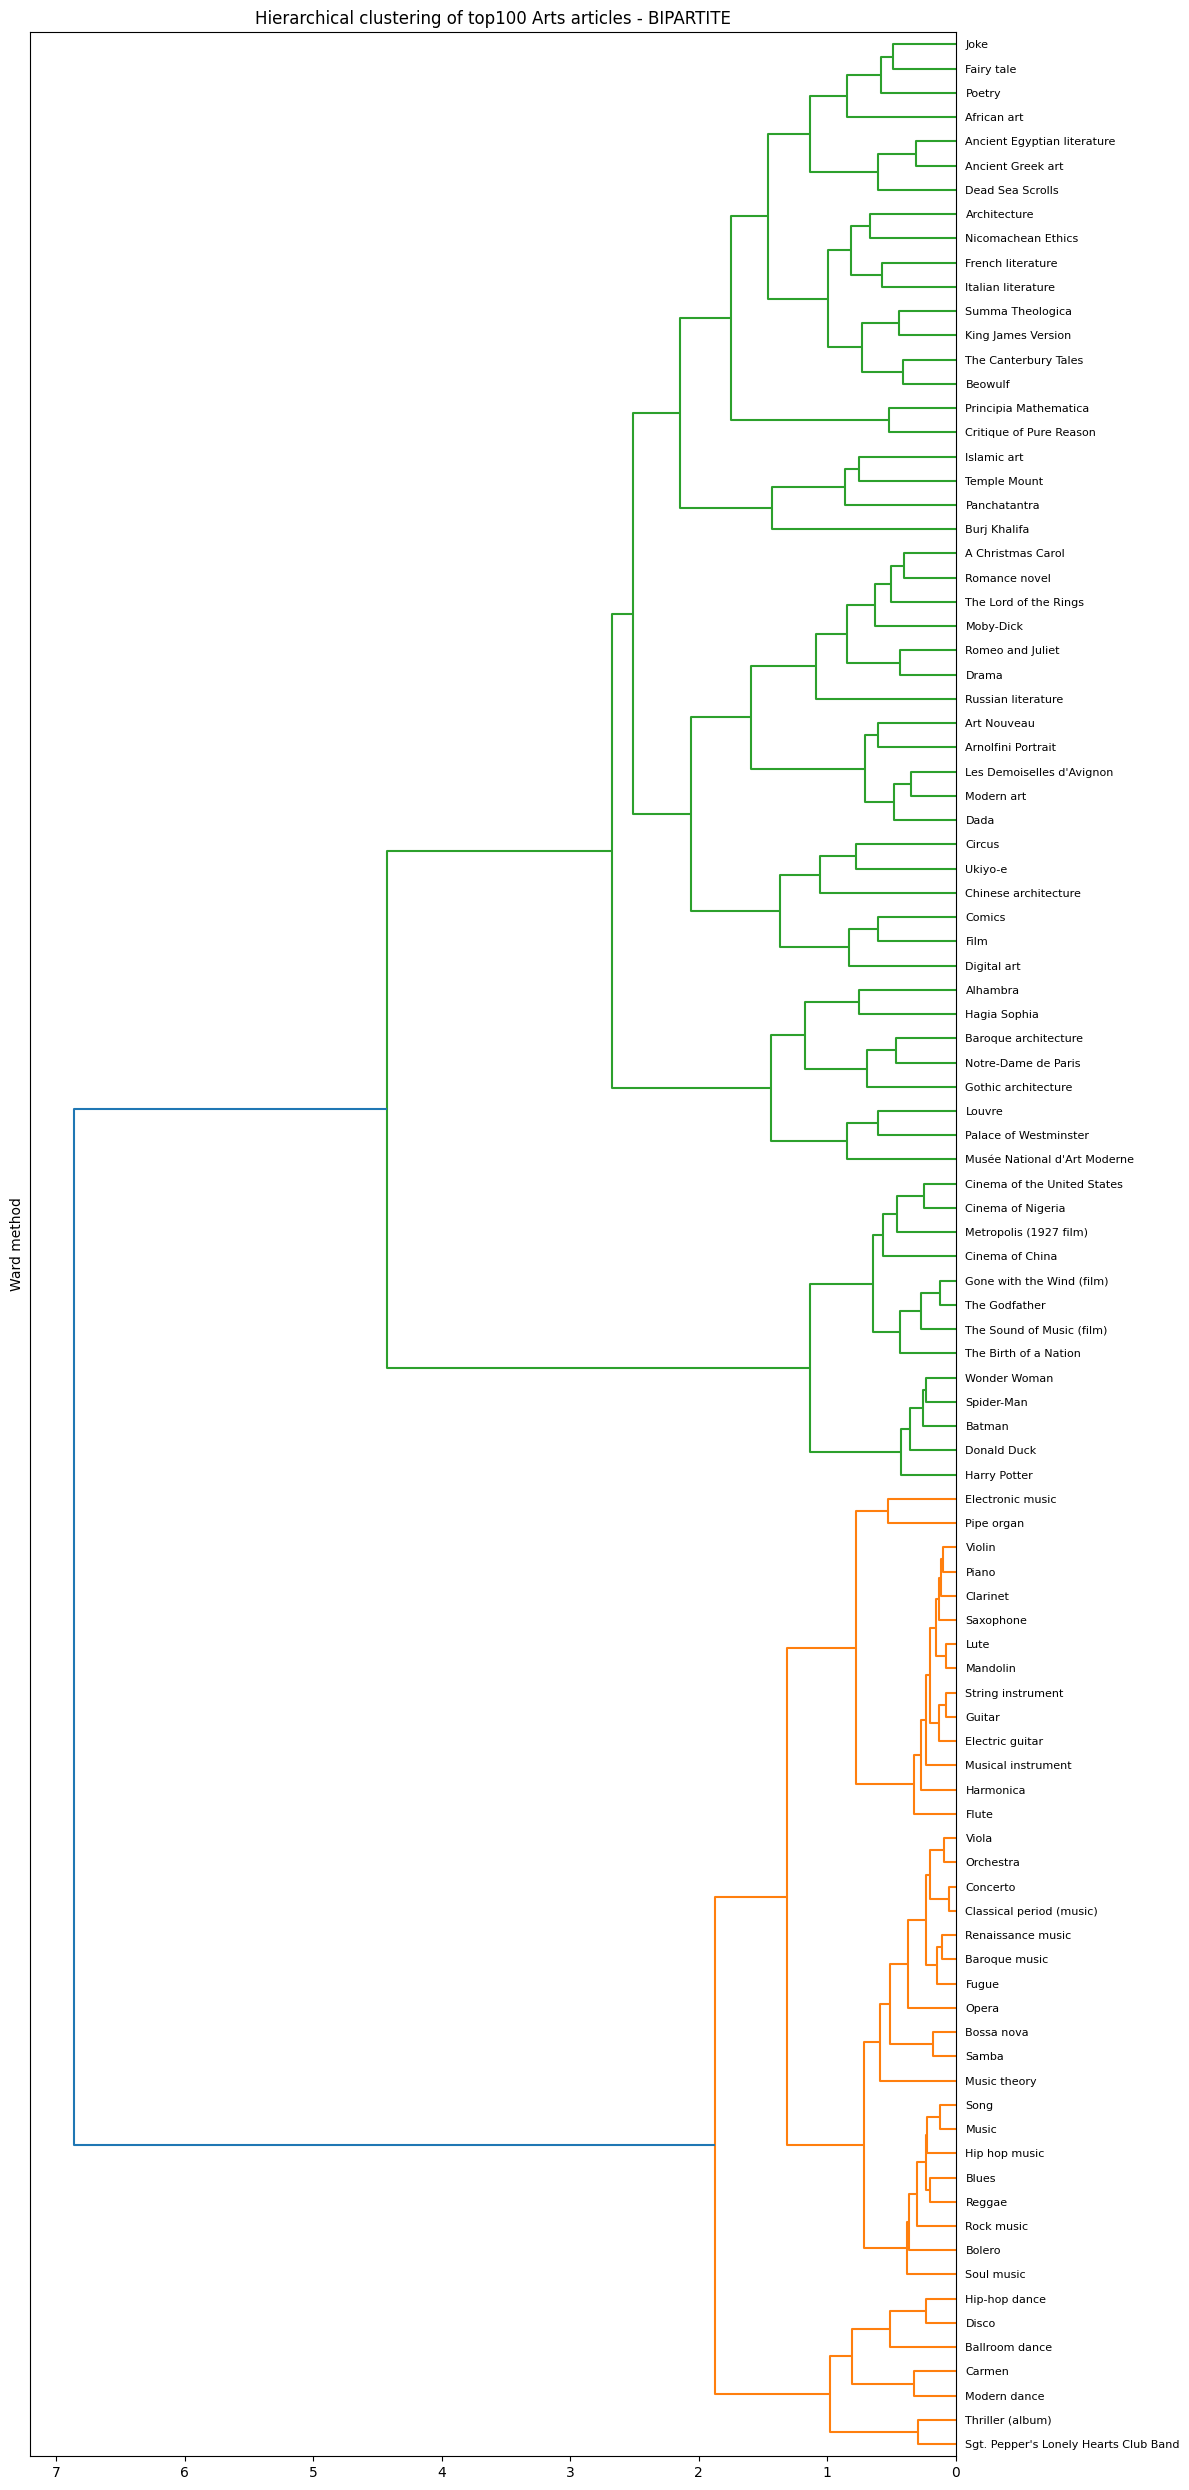

In [47]:
# Display dendogram - bipartite graph
arts_emb = embeddings[top100_arts]

Z = linkage(arts_emb, method='ward')

plt.figure(figsize=(12, 25))

dendrogram(
    Z,
    labels=names[top100_arts],
    orientation="left",
    leaf_font_size=8
)

plt.title("Hierarchical clustering of top100 Arts articles - BIPARTITE")
plt.ylabel("Ward method")
plt.tight_layout()
plt.show()


In [48]:
#### List the 10 articles and the 10 words that are closest to the word painting in the embedding space.
B = biadjacency
A_bip = bmat([
    [None, B],
    [B.T, None]
], format="csr")

emb = spectral.fit_transform(A_bip)

n_articles, n_words = biadjacency.shape

article_emb = emb[:n_articles]
word_emb = emb[n_articles:]

idx_painting = np.where(words == "painting")[0][0]
painting_emb = word_emb[idx_painting]

scores_articles = article_emb @ painting_emb
scores_words = word_emb @ painting_emb

scores_words[idx_painting] = -np.inf

top_articles = np.argsort(scores_articles)[::-1][:10]
top_words = np.argsort(scores_words)[::-1][:10]

print("Closest articles:")
for i in top_articles:
    print(names[i], scores_articles[i])

print("\nClosest words:")
for i in top_words:
    print(words[i], scores_words[i])

Closest articles:
Les Demoiselles d'Avignon 0.9523242961800629
Hieronymus Bosch 0.9468583759902416
Rembrandt 0.9442168752678648
Modern art 0.9410850597042135
Peter Paul Rubens 0.939374162497912
Gian Lorenzo Bernini 0.9358911764142103
Symbolism (arts) 0.932015256854897
Constantin Brâncuși 0.9286501784867448
Pieter Bruegel the Elder 0.9286468512427526
Johannes Vermeer 0.9259757595082305

Closest words:
Rembrandt 0.9689055974067893
Netherlandish 0.9685990482944974
Bruegel 0.9635629126920728
Painters 0.9591278187133888
Demoiselles 0.9586676148811772
Rubens 0.9586037671885892
portraiture 0.9567965585518204
draughtsman 0.9517983346775976
Vermeer 0.9516402978473617
Lautrec 0.9511881850119273


## To do

* Prove that the average cosine similarity between vectors in some set $S$ is equal to the square norm of the centroid of $S$.

$$
S=\{v_1,\ldots,v_n\}
$$
$$
\mu = \frac 1 n \sum_{i=1}^n v_i
$$

For the following questions, first consider the graph of links, then the bipartite graph between articles and words:

* Compute the average cosine similarity between articles of the **Mammals** category (see hierarchical labels).
* Compare with the expected cosine similarity between two articles sampled uniformly at random.
* Defining a category as **topical** if its average cosine similarity is close to 1, rank the 11 categories (Arts, History,...) by topicality.
* List the 10 most topical and the 10 less topical hierarchical categories having at least 10 articles (like **Mammals**). Comment the results.

## **Answers**

- Assuming the vectors in S are unit vectors, i.e.,$\|v_i\|=1 \qquad \forall i=1,\ldots,n$ .

Then, the cosine similarity between two vectors is given by $\cos(v_i,v_j)=v_i^\top v_j.$

Therefore, we obtain the average cosine similarity over all pairs of vectors with

$$
\frac{1}{n^2}\sum_{i=1}^{n}\sum_{j=1}^{n}\cos(v_i,v_j)
=
\frac{1}{n^2}\sum_{i=1}^{n}\sum_{j=1}^{n}v_i^\top v_j.
$$

Using bilinearity of the dot product,

$$
\frac{1}{n^2}\sum_{i=1}^{n}\sum_{j=1}^{n}v_i^\top v_j
=
\left(\frac{1}{n}\sum_{i=1}^{n}v_i\right)^\top
\left(\frac{1}{n}\sum_{j=1}^{n}v_j\right).
$$

Now, using the centroid definition

$$
\left(\frac{1}{n}\sum_{i=1}^{n}v_i\right)^\top
\left(\frac{1}{n}\sum_{j=1}^{n}v_j\right)
=
\mu^\top \mu
= \|\mu\|^2
$$

- Even though Math appears as the most topical. We see that the hierarchical Math categories are not between the top10. That means that some categories have many hierarchichal categories highly connected between its own nodes, but poorly connected to other hierarchical categories.

In [49]:
print(names_labels_hierarchy)

['Arts|||Architecture|||General'
 'Arts|||Architecture|||Specific structures'
 'Arts|||Architecture|||Specific structures|||Seven Wonders of the Ancient World'
 ... 'Technology|||Transportation|||Road transport|||Driving'
 'Technology|||Transportation|||Road transport|||Road'
 'Technology|||Transportation|||Road transport|||Road|||Highway']


In [50]:
# compute the embedding of the TRANSITION MATRIX
transition_matrix = adjacency / adjacency.sum(axis=1)
embeddings = spectral.fit_transform(transition_matrix)

/home/andre/telecom/graphmine/labs/venv/lib/python3.10/site-packages/scipy/sparse/_base.py:767: RuntimeWarning: divide by zero encountered in divide
  recip = np.true_divide(1., other)


In [51]:
#### Compute the average cosine similarity between articles of the Mammals category

  #Compute embeddings
embeddings = spectral.fit_transform(adjacency)
idx_mm = np.where(["Mammals" in x for x in names_labels_hierarchy])[0]
articles_mm = np.where(np.isin(labels_hierarchy, idx_mm))[0]
emb_mm = embeddings[articles_mm]

  # Centroid
centroid = emb_mm.mean(axis=0)

  # Average cosine similarity over all pairs
avg_cosine = np.dot(centroid, centroid)

print(avg_cosine)

0.8293941941590485


In [52]:
#### Compare with the expected cosine similarity between two articles sampled uniformly at random.

emb_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
global_centroid = emb_norm.mean(axis=0)
expected_random_cosine = np.dot(global_centroid, global_centroid)

print("Average cosine similarity Mammals:", avg_cosine)
print("Expected cosine similarity between random articles:", expected_random_cosine)

Average cosine similarity Mammals: 0.8293941941590485
Expected cosine similarity between random articles: 0.006095102766712221


In [53]:
#### Defining a category as topical if its average cosine similarity is close to 1, rank the 11 categories (Arts, History,...) by topicality.

topicality = []

for label_id, label_name in enumerate(names_labels):

    idx = np.where(labels == label_id)[0]

    centroid = emb_norm[idx].mean(axis=0)

    avg_cosine = np.dot(centroid, centroid)

    topicality.append((label_name, avg_cosine))

# Rank
topicality = sorted(topicality, key=lambda x: x[1], reverse=True)

for rank, (label, score) in enumerate(topicality, start=1):
    print(f"{rank:}. {label:} {score:.4f}")

1. Mathematics 0.6573
2. Philosophy and religion 0.3985
3. Technology 0.3241
4. Biological and health sciences 0.3134
5. Geography 0.2771
6. History 0.2606
7. Physical sciences 0.2514
8. Everyday life 0.2159
9. Society and social sciences 0.2003
10. Arts 0.1866
11. People 0.0870


In [54]:
#### List the 10 most topical and the 10 less topical hierarchical categories having at least 10 articles

results = []

for label_id, label_name in enumerate(names_labels_hierarchy):

    idx = np.where(labels_hierarchy == label_id)[0]

    # Keep only categories with at least 10 articles
    if len(idx) < 10:
        continue

    centroid = emb_norm[idx].mean(axis=0)

    topicality = np.dot(centroid, centroid)

    results.append({
        "category": label_name,
        "size": len(idx),
        "topicality": topicality
    })

# Sort by topicality
results = sorted(results, key=lambda x: x["topicality"], reverse=True)

print("Most topical:")
for r in results[:10]:
    print(f"{r['topicality']:.4f}  {r['category']}")

print("\nLeast topical:")
for r in results[-10:]:
    print(f"{r['topicality']:.4f}  {r['category']}")

Most topical:
0.9981  Physical sciences|||Measurement|||Units of measurement|||Electromagnetism
0.9937  Geography|||Physical geography|||Bodies of water|||Oceans and seas|||Pacific Ocean
0.9934  Physical sciences|||Chemistry|||Chemical substances|||Chemical elements|||Chemical element groups
0.9927  Physical sciences|||Chemistry|||Chemical substances|||Chemical elements|||Chemical elements
0.9925  People|||Sports figures|||Individual sports|||Athletics
0.9904  Biological and health sciences|||Anatomy and morphology|||Plant|||General
0.9901  Physical sciences|||Astronomy|||Astronomical objects|||Notable stars
0.9882  Geography|||Countries|||Africa|||Central Africa
0.9865  Everyday life|||Sports and recreation|||Sports|||Combat sport and martial arts
0.9857  Geography|||Countries|||Africa|||West Africa

Least topical:
0.4022  Arts|||Literature|||Specific works|||Fiction|||Fiction of antiquity
0.3909  Arts|||Literature|||Specific works|||Nonfiction|||Nonfiction of early printed book era
0

In [55]:
#### Repeat everything for bipartite

#Compute embeddings
embeddings = spectral.fit_transform(biadjacency)

  #find Mammals category
idx_mm = np.where(["Mammals" in x for x in names_labels_hierarchy])[0]
articles_mm = np.where(np.isin(labels_hierarchy, idx_mm))[0]

  #Normalized embeddings of Mammals articles
emb_mm = embeddings[articles_mm]
emb_mm_norm = emb_mm / np.linalg.norm(emb_mm, axis=1, keepdims=True)

  # Centroid
centroid = emb_mm_norm.mean(axis=0)

  #Average cosine similarity over all pairs
avg_cosine = np.dot(centroid, centroid)

print(avg_cosine)

0.8544174530113083


In [56]:
#### Compare with the expected cosine similarity between two articles sampled uniformly at random.

emb_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
global_centroid = emb_norm.mean(axis=0)
expected_random_cosine = np.dot(global_centroid, global_centroid)

print("Average cosine similarity Mammals:", avg_cosine)
print("Expected cosine similarity between random articles:", expected_random_cosine)

Average cosine similarity Mammals: 0.8544174530113083
Expected cosine similarity between random articles: 0.006870975506168217


In [57]:
#### Defining a category as topical if its average cosine similarity is close to 1, rank the 11 categories (Arts, History,...) by topicality.

topicality = []

for label_id, label_name in enumerate(names_labels):

    idx = np.where(labels == label_id)[0]

    centroid = emb_norm[idx].mean(axis=0)

    avg_cosine = np.dot(centroid, centroid)

    topicality.append((label_name, avg_cosine))

# Rank
topicality = sorted(topicality, key=lambda x: x[1], reverse=True)

for rank, (label, score) in enumerate(topicality, start=1):
    print(f"{rank:}. {label:} {score:.4f}")

1. Mathematics 0.8385
2. Geography 0.5480
3. Philosophy and religion 0.4881
4. Technology 0.3756
5. Arts 0.2899
6. Biological and health sciences 0.2788
7. Everyday life 0.2773
8. Physical sciences 0.2501
9. History 0.2442
10. Society and social sciences 0.2433
11. People 0.1925


In [58]:
#### List the 10 most topical and the 10 less topical hierarchical categories having at least 10 articles

results = []

for label_id, label_name in enumerate(names_labels_hierarchy):

    idx = np.where(labels_hierarchy == label_id)[0]

    # Keep only categories with at least 10 articles
    if len(idx) < 10:
        continue

    centroid = emb_norm[idx].mean(axis=0)

    topicality = np.dot(centroid, centroid)

    results.append({
        "category": label_name,
        "size": len(idx),
        "topicality": topicality
    })

# Sort by topicality
results = sorted(results, key=lambda x: x["topicality"], reverse=True)

print("Most topical:")
for r in results[:10]:
    print(f"{r['topicality']:.4f}  {r['category']}")

print("\nLeast topical:")
for r in results[-10:]:
    print(f"{r['topicality']:.4f}  {r['category']}")

Most topical:
0.9922  People|||Sports figures|||Team sports|||Association football
0.9819  Physical sciences|||Astronomy|||Astronomical objects|||Notable stars
0.9807  Mathematics|||Algebra|||Abstract algebra
0.9803  Mathematics|||Geometry|||Topology
0.9750  People|||Musicians and composers|||Western art music|||Composers|||20th century modern
0.9745  Philosophy and religion|||Eastern religions|||Hinduism
0.9700  Arts|||Modern visual arts|||Filmmaking|||Films|||Drama film
0.9624  People|||Musicians and composers|||Popular music|||Rock
0.9610  Everyday life|||Sports and recreation|||Sports|||Athletics|||Track and field
0.9605  Biological and health sciences|||Health, medicine and disease|||Morbidity|||Mental disorder

Least topical:
0.4823  History|||History by country|||Asia
0.4541  Everyday life|||Sports and recreation|||Entertainment|||Entertainment and leisure
0.4492  People|||Scientists, inventors and mathematicians|||Ancient figures|||Post-classical
0.4492  Society and social scie